# 予測・提出ファイル生成 v2（類似度特徴量あり）

v1（predicting.ipynb）からの変更点：
- testの各サンプルとtrainの樹種平均スペクトルとの距離を特徴量に追加

**入力ファイル**

| ファイル | 内容 |
|---|---|
| `models/model_v2.pkl` | 学習済みRidgeモデル（類似度特徴量あり） |
| `models/X_test.npy` | 前処理済みtest特徴量（PCA済み） |
| `models/y_train.npy` | log変換済みtrain目的変数（分布確認用） |
| `models/test_sample_numbers.npy` | testのsample_number |
| `models/species_centroids.npy` | train各樹種の平均スペクトル |
| `models/species_centroid_ids.npy` | 樹種番号の対応表 |

**出力ファイル**

| ファイル | 内容 |
|---|---|
| `submission.csv` | SIGNATEへの提出ファイル |

## 1. ライブラリの読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.spatial.distance import cdist

# Noto Sans CJK JP を指定（環境に既存のフォント）
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['figure.dpi'] = 120

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 2. モデル・データの読み込み

In [2]:
model       = joblib.load('models/model_v2.pkl')
X_test      = np.load('models/X_test.npy')
y_train_log = np.load('models/y_train.npy')
test_ids    = np.load('models/test_sample_numbers.npy')
centroids   = np.load('models/species_centroids.npy')
centroid_ids= np.load('models/species_centroid_ids.npy')

print(f'モデル      : {type(model).__name__}  alpha={model.alpha}')
print(f'X_test      : {X_test.shape}')
print(f'centroids   : {centroids.shape}  （{len(centroid_ids)}樹種 × 波数）')
print(f'test_ids    : {test_ids.shape}')

モデル      : Ridge  alpha=1100
X_test      : (550, 20)
centroids   : (13, 1555)  （13樹種 × 波数）
test_ids    : (550,)


## 3. testの類似度特徴量を計算

learning_v2で保存したtrainの樹種平均スペクトル（centroids）を使って、
testの各サンプルとの距離を計算する。
testサンプル同士の情報は一切使わないのでルール違反にならない。

In [3]:
# testのSNV済みスペクトルを読み込む
test_raw = pd.read_csv('../data/test.csv', encoding='shift-jis')
test_raw.columns = (
    ['sample_number', 'species_number', 'species_name']
    + list(test_raw.columns[3:])
)
spec_cols = list(test_raw.columns[3:])

def snv(X):
    return (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)

X_test_snv = snv(test_raw[spec_cols].values)

# testの各サンプルとtrainの各樹種平均スペクトルとの距離
sim_test = cdist(X_test_snv, centroids, metric='euclidean')

# PCA特徴量 + 類似度特徴量を結合
X_test_final = np.hstack([X_test, sim_test])

print(f'X_test_snv  : {X_test_snv.shape}')
print(f'sim_test    : {sim_test.shape}  （550サンプル × 13樹種との距離）')
print(f'X_test_final: {X_test_final.shape}  （PCA20次元 + 類似度13次元）')

X_test_snv  : (550, 1555)
sim_test    : (550, 13)  （550サンプル × 13樹種との距離）
X_test_final: (550, 33)  （PCA20次元 + 類似度13次元）


## 4. 予測の実行

In [4]:
y_pred_log = model.predict(X_test_final)
y_pred     = np.expm1(y_pred_log)
y_pred     = np.clip(y_pred, 0, None)

print('予測値の統計（含水率 %）')
print(f'  min   : {y_pred.min():.2f}')
print(f'  mean  : {y_pred.mean():.2f}')
print(f'  median: {np.median(y_pred):.2f}')
print(f'  max   : {y_pred.max():.2f}')

予測値の統計（含水率 %）
  min   : 9.13
  mean  : 38.77
  median: 18.61
  max   : 139.73


## 5. 予測値の分布確認

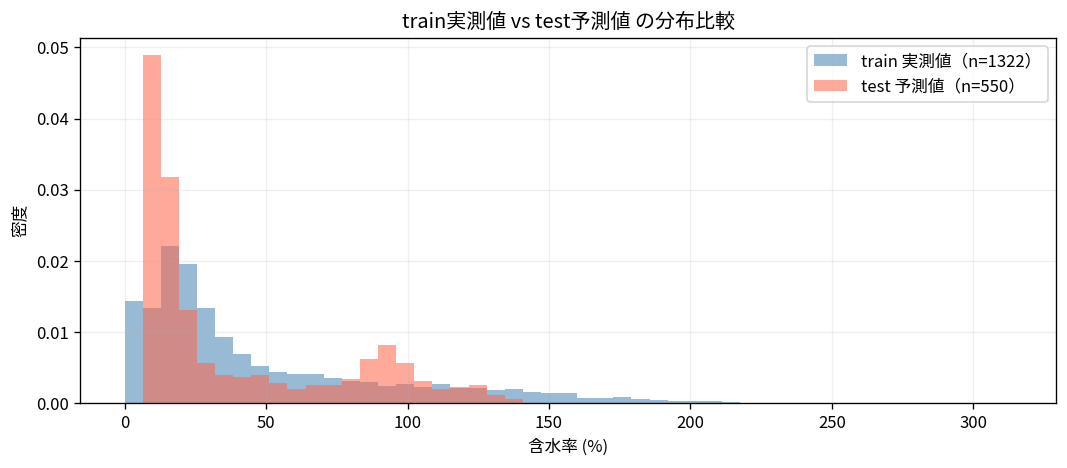

train実測値 中央値: 29.05%
test予測値  中央値: 18.61%


In [5]:
y_train_orig = np.expm1(y_train_log)

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, max(y_train_orig.max(), y_pred.max()) * 1.05, 50)
ax.hist(y_train_orig, bins=bins, alpha=0.55, color='steelblue',
        label=f'train 実測値（n={len(y_train_orig)}）', density=True)
ax.hist(y_pred, bins=bins, alpha=0.55, color='tomato',
        label=f'test 予測値（n={len(y_pred)}）', density=True)
ax.set_xlabel('含水率 (%)')
ax.set_ylabel('密度')
ax.set_title('train実測値 vs test予測値 の分布比較')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'train実測値 中央値: {np.median(y_train_orig):.2f}%')
print(f'test予測値  中央値: {np.median(y_pred):.2f}%')

## 6. 提出ファイルの生成

In [6]:
submission = pd.DataFrame({
    'sample_number'   : test_ids,
    'moisture_content': y_pred,
})
submission.to_csv('submission.csv', index=False, header=False)

print('提出ファイル生成完了: submission.csv')
print(f'行数: {len(submission)}  （期待値: 550）')
print()
print('先頭5行:')
print(submission.head().to_string(index=False))

提出ファイル生成完了: submission.csv
行数: 550  （期待値: 550）

先頭5行:
 sample_number  moisture_content
            95        137.915431
            96         99.603220
            97        101.820993
            98        111.448968
            99        120.701581


## 7. フォーマット確認

In [9]:
sample_sub = pd.read_csv('../data/sample_submit.csv', encoding='shift-jis', header=None)
my_sub     = pd.read_csv('submission.csv', header=None)

print('=== フォーマット確認 ===')
print(f'sample_submit 行数: {len(sample_sub)}  列数: {sample_sub.shape[1]}')
print(f'自分の提出    行数: {len(my_sub)}  列数: {my_sub.shape[1]}')
print(f'sample_number の一致: {(sample_sub[0].values == my_sub[0].values).all()}')

=== フォーマット確認 ===
sample_submit 行数: 550  列数: 2
自分の提出    行数: 550  列数: 2
sample_number の一致: True
